# 1. problem Stament
#### The objective of this project is to analyze home loan application data and build a predictive model to identify customers who are likely to default on a loan.
#### The target variable is TARGET where 1 indicates a defaulter and 0 indicates a non-defaulter.

## 2. Dataset Description
###2.1 application_train.
 The application_train.csv dataset is the main table of this project.
Each row represents a single loan application submitted by a customer.
It contains:

* Applicant’s personal, demographic, and financial information

* Loan-related details such as credit amount, annuity, and income
* The target variable TARGET, where:

  *   1 indicates the customer defaulted on the loan

  * 0 indicates the customer did not default

* This table acts as the base dataset, and all other datasets are linked to it using the key SK_ID_CURR.
### 2.2 bureau.csv
The bureau.csv dataset contains information about the previous loans taken by applicants from other financial institutions, as reported by the Credit Bureau.

Each row corresponds to one previous credit record of a customer.
A single customer can have multiple rows in this table.

This dataset helps in understanding:

  * Applicant’s credit history

  * Number of past loans

  * Credit amounts and repayment behavior
  
  It is linked to application_train.csv using SK_ID_CURR
### 2.3 bureau_balance.csv
The bureau_balance.csv dataset provides monthly balance information for each previous credit listed in the bureau.csv table.

Each row represents:

  * One month of credit history

  * One specific previous loan

This dataset is useful for analyzing:

  * Delinquency patterns over time

   * Duration and status of past credits

It is linked to bureau.csv using the key SK_ID_BUREAU.

### 2.4 previous_application.csv
The previous_application.csv dataset contains details of all previous loan applications made by customers to Home Credit before the current application.

Each row represents one previous loan application.

This dataset provides insights into:

  * Approval or rejection history

   * Previous loan amounts and terms

  * Customer’s past relationship with Home Credit

It is linked to the main dataset using SK_ID_CURR.
### 2.5 installments_payments.csv
The installments_payments.csv dataset records the repayment history of previously approved loans from Home Credit.

Each row corresponds to:

   * A single installment payment

   * Or a missed installment payment

This dataset helps evaluate:

  * Payment delays

   * Default tendencies

   * Consistency in repayments

It is linked to previous_application.csv and the main table through SK_ID_CURR.
###  2.6 POS_CASH_balance.csv

The POS_CASH_balance.csv dataset contains monthly snapshots of Point-of-Sale (POS) and cash loans previously taken by customers from Home Credit.

Each row represents:

  * One month of loan history

  * One previous POS or cash loan

This dataset is useful for analyzing:

  * Short-term loan behavior

  * Installment patterns and overdue trends

It is connected to the main dataset using SK_ID_CURR.
### 2.7 credit_card_balance.csv
The credit_card_balance.csv dataset provides monthly balance information for credit cards issued by Home Credit to customers.

Each row corresponds to:

  * One month of credit card usage history

  * One credit card account

This dataset helps understand:

* Credit card utilization

* Payment behavior

* Risk exposure due to revolving credit

It is linked to the main dataset using SK_ID_CURR.

# 3.Data Loading

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
app=pd.read_csv('/content/application_train.csv')
bur=pd.read_csv('/content/bureau.csv')
bur_bal=pd.read_csv('/content/bureau_balance.csv')
prev=pd.read_csv('/content/previous_application.csv')
inst=pd.read_csv('/content/installments_payments.csv')
pos=pd.read_csv('/content/POS_CASH_balance.csv')
cc=pd.read_csv('/content/credit_card_balance.csv')

## 4. Initial Data Understanding
This section focuses on getting a first-level understanding of all datasets.
We examine dataset size, structure, data types, and missing values to identify early data quality issues before performing detailed analysis and modeling.



### 4.1 Shape of Datasets
In this step, we check the number of rows and columns in each dataset.
This helps us understand:
* The scale of the data

* Which tables are large and may require aggregation

* Whether some datasets contain multiple records per customer

In [ ]:
print("application_train:", app.shape)
print("bureau:", bur.shape)
print("bureau_balance:", bur_bal.shape)
print("previous_application:", prev.shape)
print("installments_payments:", inst.shape)
print("POS_CASH_balance:", pos.shape)
print("credit_card_balance:", cc.shape)


application_train: (307511, 122)
bureau: (1716428, 17)
bureau_balance: (27299925, 3)
previous_application: (1670214, 37)
installments_payments: (13605401, 8)
POS_CASH_balance: (10001358, 8)
credit_card_balance: (3840312, 23)


Observation: The dataset contains a large number of records with multiple features, indicating a rich set of information for analyzing customer loan behavior.

### 4.2 Data Types and Null Values
Here, we examine the data types of each column and identify missing values.
This step is critical because:

* Machine learning models require numerical inputs

* Missing values must be handled appropriately

* Incorrect data types can lead to modeling errors

In [ ]:
# Check missing values count
app.info()
app.isnull().sum().sort_values(ascending=False).head(10)



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


**Observation:**
The dataset contains a mix of numerical and categorical features. Several columns have missing values, with some features having a high proportion of null entries. These missing values will be handled during the data cleaning phase.



### 4.3 Sample Records
Viewing a few sample records helps us:

* Understand the meaning of each column

* Verify that data is loaded correctly

* Identify potential data quality issues

In [ ]:
app.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
app.tail(10)

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
307501,456245,0,Cash loans,F,N,Y,3,81000.0,269550.0,11871.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307502,456246,0,Cash loans,F,N,Y,1,94500.0,225000.0,10620.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
307503,456247,0,Cash loans,F,N,Y,0,112500.0,345510.0,17770.5,...,0,0,0,0,0.0,0.0,0.0,1.0,0.0,2.0
307504,456248,0,Cash loans,F,N,Y,0,153000.0,331920.0,16096.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307505,456249,0,Cash loans,F,N,Y,0,112500.0,225000.0,22050.0,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,0.0
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
307510,456255,0,Cash loans,F,N,N,0,157500.0,675000.0,49117.5,...,0,0,0,0,0.0,0.0,0.0,2.0,0.0,1.0


In [ ]:
app.isnull().sum().sort_values(ascending=False).head(10)

,0
COMMONAREA_AVG,214865
COMMONAREA_MODE,214865
COMMONAREA_MEDI,214865
NONLIVINGAPARTMENTS_MEDI,213514
NONLIVINGAPARTMENTS_MODE,213514
NONLIVINGAPARTMENTS_AVG,213514
FONDKAPREMONT_MODE,210295
LIVINGAPARTMENTS_AVG,210199
LIVINGAPARTMENTS_MEDI,210199
LIVINGAPARTMENTS_MODE,210199


**Observation:**
The sample records show applicant demographic information, income details, employment status, and loan-related attributes. The target variable is binary and suitable for classification.


### 4.4 Target Variable Distribution


In [ ]:
app['TARGET'].value_counts()


,count
TARGET,
0,282686
1,24825


In [ ]:
app['TARGET'].value_counts(normalize=True) * 100


,proportion
TARGET,
0,91.927118
1,8.072882


**Observation:**
The target variable is imbalanced, with a significantly higher proportion of non-defaulters compared to defaulters.


### 4.5 Numerical Feature Summary
This step provides a statistical summary of numerical features, including mean, median, and range, helping to understand data distribution and potential outliers.

In [ ]:
app.describe().T

,count,mean,std,min,25%,50%,75%,max
SK_ID_CURR,307511.0,278180.518577,102790.175348,100002.0,189145.5,278202.0,367142.5,456255.0
TARGET,307511.0,0.080729,0.272419,0.0,0.0,0.0,0.0,1.0
CNT_CHILDREN,307511.0,0.417052,0.722121,0.0,0.0,0.0,1.0,19.0
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,25650.0,112500.0,147150.0,202500.0,117000000.0
AMT_CREDIT,307511.0,599025.999706,402490.776996,45000.0,270000.0,513531.0,808650.0,4050000.0
...,...,...,...,...,...,...,...,...
AMT_REQ_CREDIT_BUREAU_DAY,265992.0,0.007000,0.110757,0.0,0.0,0.0,0.0,9.0
AMT_REQ_CREDIT_BUREAU_WEEK,265992.0,0.034362,0.204685,0.0,0.0,0.0,0.0,8.0
AMT_REQ_CREDIT_BUREAU_MON,265992.0,0.267395,0.916002,0.0,0.0,0.0,0.0,27.0
AMT_REQ_CREDIT_BUREAU_QRT,265992.0,0.265474,0.794056,0.0,0.0,0.0,0.0,261.0


**Observation:**
Numerical features such as income, credit amount, and annuity show wide variations, indicating the presence of outliers and different customer segments.


### 4.6 Categorical Feature Overview
Examining categorical features helps in understanding the diversity of categories and identifying features that require encoding.


In [ ]:
app.select_dtypes(include='object').nunique().sort_values(ascending=False)


,0
ORGANIZATION_TYPE,58
OCCUPATION_TYPE,18
NAME_INCOME_TYPE,8
NAME_TYPE_SUITE,7
WALLSMATERIAL_MODE,7
WEEKDAY_APPR_PROCESS_START,7
NAME_FAMILY_STATUS,6
NAME_HOUSING_TYPE,6
NAME_EDUCATION_TYPE,5
FONDKAPREMONT_MODE,4


**Observation:**
Some categorical variables have a high number of unique values, which may increase model complexity and require careful encoding.


### 4.7 Summary of Initial Data Understanding


From the initial data understanding, it is observed that the dataset contains a mix of numerical and categorical features with missing values. The target variable is imbalanced, and several features show wide value ranges. These insights highlight the need for data cleaning, feature engineering, and appropriate modeling strategies in the subsequent steps.


## 5. Exploratory Data Analysis (EDA)


Exploratory Data Analysis (EDA) is performed to understand the underlying patterns, relationships, and distributions present in the dataset.

This step helps identify important variables, detect anomalies, and gain insights that guide feature engineering and model selection

### 5.1 Target Variable Analysis


The target variable represents whether a customer has defaulted on a loan.
Analyzing its distribution helps understand class imbalance in the dataset.

In [ ]:
app['TARGET'].value_counts()


,count
TARGET,
0,282686
1,24825


In [ ]:
app['TARGET'].value_counts(normalize=True) * 100


,proportion
TARGET,
0,91.927118
1,8.072882


# Importing viluziation libaries

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

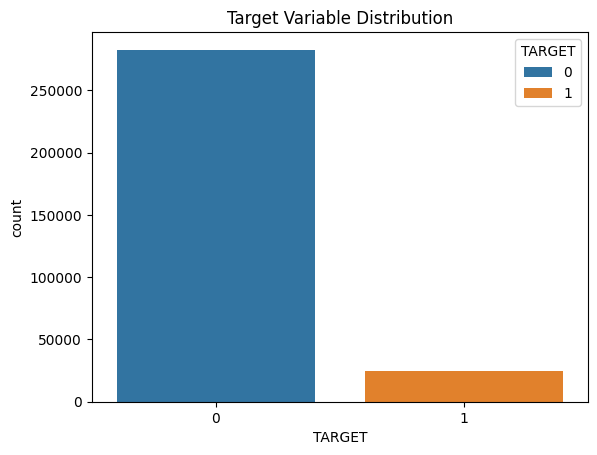

In [ ]:
sns.countplot(x='TARGET', hue= "TARGET", data=app)
plt.title("Target Variable Distribution")
plt.show()

**Observation:**
The dataset is highly imbalanced, with a much larger proportion of non-defaulters compared to defaulters. This imbalance must be considered during model evaluation.


### 5.2 Numerical Feature Distribution


This step analyzes the distribution of important numerical variables to understand customer financial characteristics and identify outliers.

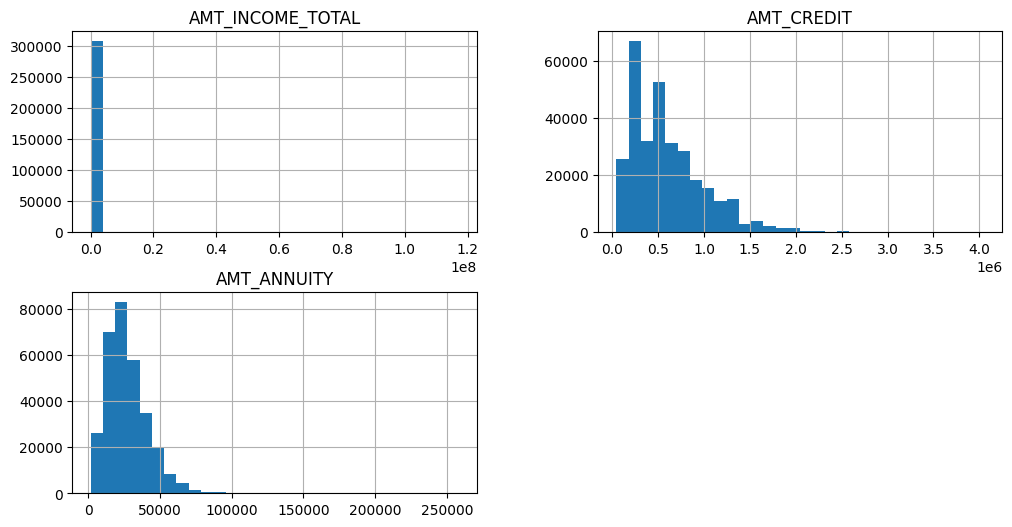

In [ ]:
num_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']
app[num_cols].hist(bins=30, figsize=(12,6))
plt.show()


**Observation:**
Income, credit amount, and annuity values are right-skewed, indicating that a small number of customers have very high financial values.


### 5.3 Outlier Detection


Boxplots are used to visually identify extreme values (outliers) in numerical features.

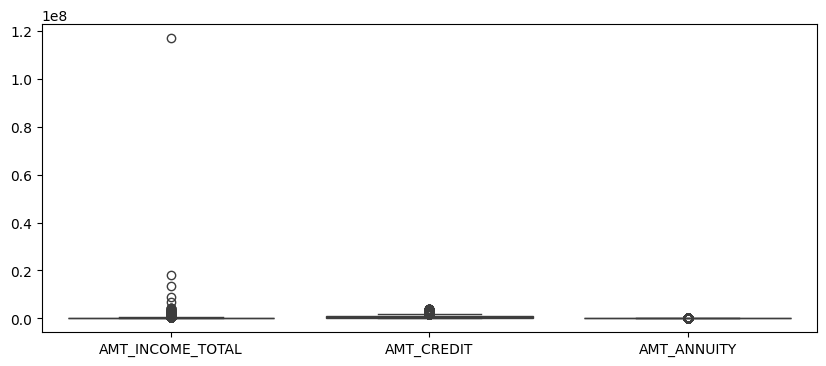

In [ ]:
plt.figure(figsize=(10,4))
sns.boxplot(data=app[num_cols])
plt.show()


**Observation:**
Several numerical variables contain extreme values, confirming the presence of outliers that may need treatment during data cleaning.


### 5.4 Categorical Feature Analysis


This step analyzes categorical variables to understand customer segmentation and their relationship with loan default behavior.

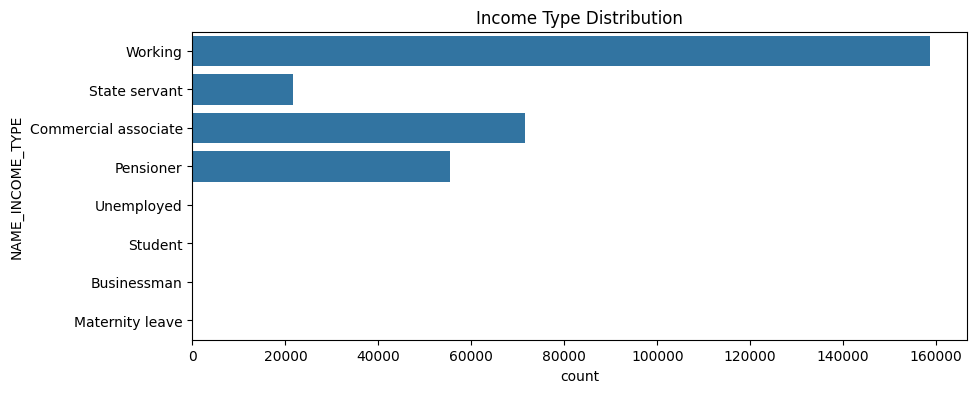

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(y='NAME_INCOME_TYPE', data=app)
plt.title("Income Type Distribution")
plt.show()


**Observation:**
Most applicants belong to the working income group, indicating that employment status plays an important role in loan applications.


### 5.5 Categorical Features vs Target


Comparing categorical features against the target variable helps identify customer segments with higher default risk.

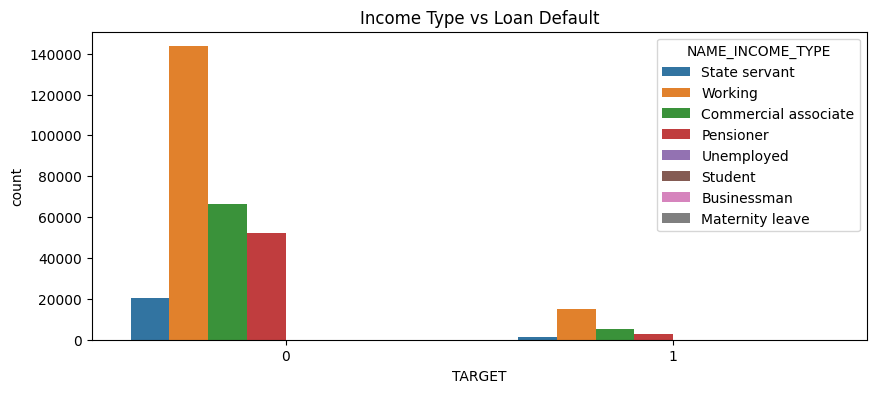

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(x='TARGET', hue='NAME_INCOME_TYPE', data=app)
plt.title("Income Type vs Loan Default")
plt.show()


**Observation:**
Certain income categories show a higher proportion of defaulters, suggesting that income source is an important factor in default prediction.


### 5.6 Correlation Analysis


Correlation analysis helps identify relationships between numerical variables and the target variable.

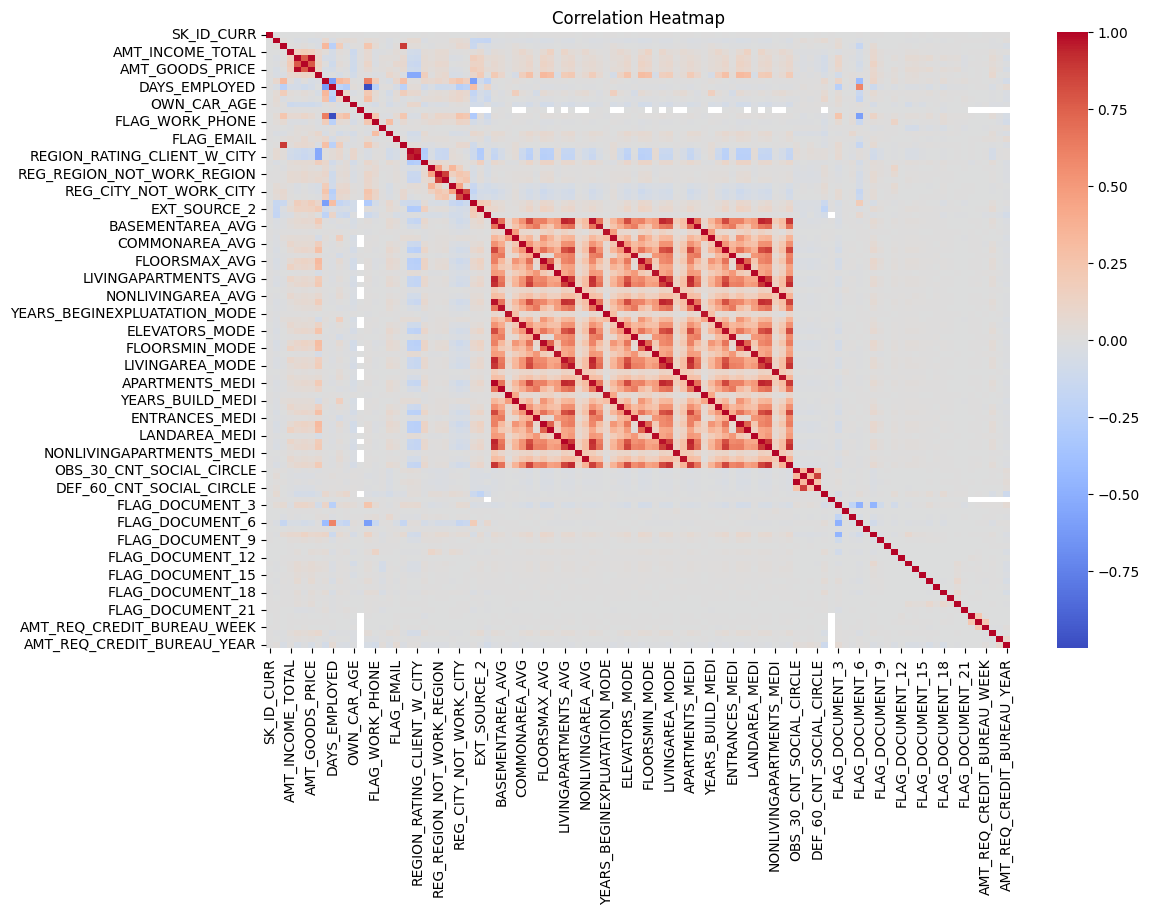

In [ ]:
corr = app.select_dtypes(include=np.number).corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

**Observation:**
Some numerical variables show moderate correlation with the target variable, indicating their potential importance in predicting loan default.


### 5.8 Applicant Income vs Loan Default


This plot compares applicant income levels between defaulters and non-defaulters to understand whether income influences loan default behavior.

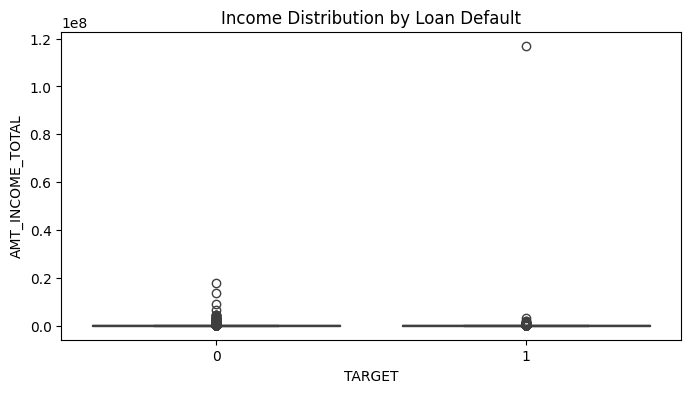

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='TARGET', y='AMT_INCOME_TOTAL', data=app)
plt.title("Income Distribution by Loan Default")
plt.show()


**Observation:**
Defaulters generally have lower median income compared to non-defaulters, indicating income level is an important factor in default risk.


### 5.9 Credit Amount vs Loan Default


This plot examines how loan credit amounts differ between defaulters and non-defaulters.

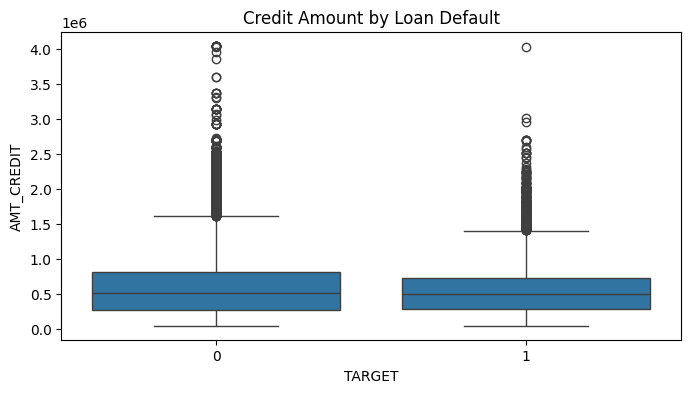

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='TARGET', y='AMT_CREDIT', data=app)
plt.title("Credit Amount by Loan Default")
plt.show()


**Observation:**
Customers who default tend to take higher credit amounts relative to their repayment capacity.


### 5.10 Age Distribution of Applicants


This plot shows the age distribution of applicants to identify age groups with higher default risk.

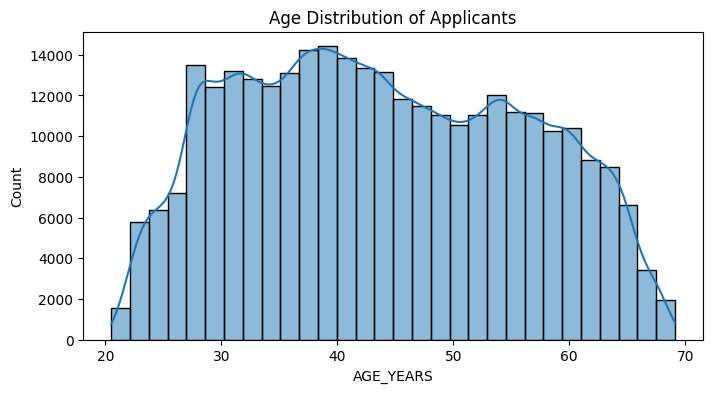

In [ ]:

# Convert age to years
app['AGE_YEARS'] = app['DAYS_BIRTH'] / -365

plt.figure(figsize=(8,4))
sns.histplot(app['AGE_YEARS'], bins=30, kde=True)
plt.title("Age Distribution of Applicants")
plt.show()



**Observation:**
Most applicants fall within the working-age group, with fewer applications from older age groups.



### 5.11 Age vs Loan Default




This plot compares age distribution between defaulters and non-defaulters.

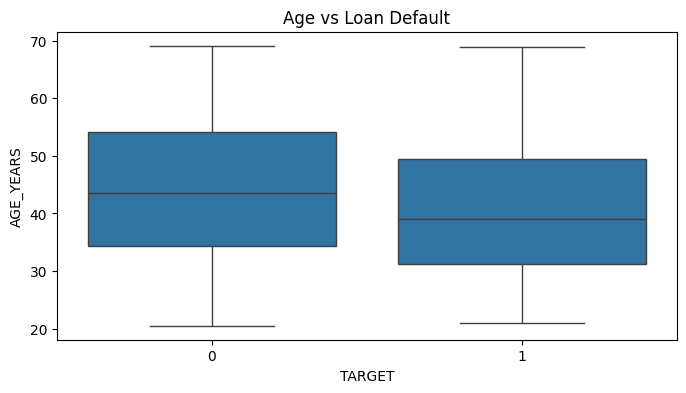

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x='TARGET', y='AGE_YEARS', data=app)
plt.title("Age vs Loan Default")
plt.show()


**Observation:**
Younger applicants show a slightly higher tendency to default compared to older applicants.


### 5.12 Pairwise Relationship Analysis


Pair plots help visualize relationships between important numerical variables and the target variable.

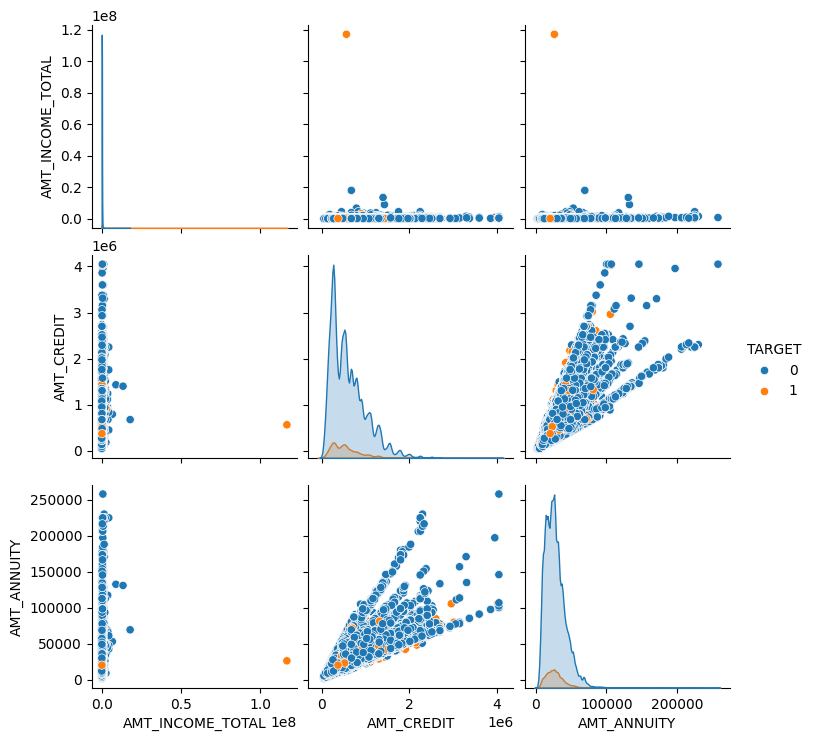

In [ ]:
sns.pairplot(
    app[['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'TARGET']],
    hue='TARGET'
)
plt.show()


**Observation:**
Defaulters and non-defaulters show overlapping distributions; however, clear differences exist in income and credit-related features.


### 5.13 EDA Summary

Exploratory Data Analysis reveals that the dataset is imbalanced with respect to the target variable. Numerical features exhibit skewness and outliers, while categorical features highlight distinct customer segments with varying default risks. These insights guide subsequent steps such as data cleaning, feature engineering, and model selection.


## 6. Data Cleaning


Data cleaning is performed to improve data quality by handling missing values, correcting inconsistencies, and treating outliers.
Clean data is essential for building reliable and accurate machine learning models.

### 6.1 Missing Value Analysis


Before handling missing values, it is important to understand how many missing values are present in each column.
This helps in deciding whether to impute values or remove columns with excessive missing data.

In [ ]:
missing_count = app.isnull().sum()
missing_percent = (missing_count / len(app)) * 100

missing_df = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_percent
}).sort_values(by='Missing_Percentage', ascending=False)

missing_df.head(10)


,Missing_Count,Missing_Percentage
COMMONAREA_AVG,214865,69.872297
COMMONAREA_MODE,214865,69.872297
COMMONAREA_MEDI,214865,69.872297
NONLIVINGAPARTMENTS_MEDI,213514,69.432963
NONLIVINGAPARTMENTS_MODE,213514,69.432963
NONLIVINGAPARTMENTS_AVG,213514,69.432963
FONDKAPREMONT_MODE,210295,68.386172
LIVINGAPARTMENTS_AVG,210199,68.354953
LIVINGAPARTMENTS_MEDI,210199,68.354953
LIVINGAPARTMENTS_MODE,210199,68.354953


**Observation:**
Several columns contain a high percentage of missing values. Columns with extremely high missing percentages may not contribute useful information.


### 6.2 Dropping High Missing Value Columns


Columns with more than 60% missing values provide limited information and may introduce noise.
Such columns are removed to simplify the dataset.

In [ ]:
cols_to_drop = missing_df[missing_df['Missing_Percentage'] > 60].index
app = app.drop(columns=cols_to_drop)

print(f"Columns dropped: {len(cols_to_drop)}")


Columns dropped: 17


**Observation:**
Columns with excessive missing values were removed, reducing noise and improving data usability.


### 6.3 Handling Remaining Missing Values


Remaining missing values are handled based on the type of data:

* Numerical columns are imputed using the median.

* Categorical columns are imputed using the mode.

This approach preserves data distribution and avoids bias from extreme values.

In [ ]:
# Separate numerical and categorical columns
num_cols = app.select_dtypes(include=['int64', 'float64']).columns
cat_cols = app.select_dtypes(include=['object']).columns

# Fill numerical columns with median
app[num_cols] = app[num_cols].fillna(app[num_cols].median())

# Fill categorical columns with mode
for col in cat_cols:
    app[col] = app[col].fillna(app[col].mode()[0])


**Observation:**
All remaining missing values were successfully handled using appropriate imputation techniques.


### 6.4 Handling Invalid and Inconsistent Values


Some columns contain special or invalid values due to data encoding conventions.
For example, extreme positive values in employment days represent missing information rather than actual employment duration.

These values are corrected for better interpretability.

In [ ]:
# Fix DAYS_EMPLOYED special value
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'].replace(365243, np.nan)
app['DAYS_EMPLOYED'] = app['DAYS_EMPLOYED'] / -365


**Observation:**
Invalid employment duration values were corrected, improving data consistency.


### 6.5 Outlier Treatment



Outliers in financial features can negatively impact model performance.
Percentile-based capping is applied to limit the effect of extreme values.



In [ ]:
# Outlier capping for key numerical columns
for col in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY']:
    lower = app[col].quantile(0.01)
    upper = app[col].quantile(0.99)
    app[col] = app[col].clip(lower, upper)


**Observation:**
Extreme values were capped, reducing skewness while retaining most of the data.


### 6.6 Final Data Quality Check


A final check is performed to ensure that the dataset is clean, consistent, and ready for feature engineering.

In [ ]:
app.isnull().sum()


,0
SK_ID_CURR,0
TARGET,0
NAME_CONTRACT_TYPE,0
CODE_GENDER,0
FLAG_OWN_CAR,0
...,...
AMT_REQ_CREDIT_BUREAU_DAY,0
AMT_REQ_CREDIT_BUREAU_WEEK,0
AMT_REQ_CREDIT_BUREAU_MON,0
AMT_REQ_CREDIT_BUREAU_QRT,0


In [ ]:
app.shape


(307511, 105)

In [ ]:
app.head()


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


## FINAL OBSERVATION

* After data cleaning, the dataset contains no missing values and fewer inconsistencies. The data is now suitable for feature engineering and predictive modeling.


## 7. Feature Engineering


Feature engineering is the process of creating new meaningful variables from existing data to improve model performance.
In this project, domain knowledge from the banking sector is used to derive features that better represent a customer’s repayment capability and risk profile.

### 7.1 Income and Credit Ratio Features


Ratios between income, credit amount, and annuity provide better insight into a customer’s repayment capacity than raw values alone.

In [ ]:
app['INCOME_CREDIT_RATIO'] = app['AMT_INCOME_TOTAL'] / app['AMT_CREDIT']
app['ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
app['CREDIT_ANNUITY_RATIO'] = app['AMT_CREDIT'] / app['AMT_ANNUITY']


/tmp/ipython-input-3034287950.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['INCOME_CREDIT_RATIO'] = app['AMT_INCOME_TOTAL'] / app['AMT_CREDIT']
/tmp/ipython-input-3034287950.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['ANNUITY_INCOME_RATIO'] = app['AMT_ANNUITY'] / app['AMT_INCOME_TOTAL']
/tmp/ipython-input-3034287950.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once us

**Observation:**
These ratio-based features help capture the financial burden of a loan relative to the applicant’s income.


### 7.2 Age Feature Creation


Age is an important demographic feature. The original age variable is stored in days and is converted into years for better interpretability.

In [ ]:
app['AGE_YEARS'] = app['DAYS_BIRTH'] / -365


/tmp/ipython-input-4176436118.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['AGE_YEARS'] = app['DAYS_BIRTH'] / -365


**Observation:**
Age in years is easier to interpret and helps identify age groups with higher default risk.


### 7.3 Employment Duration Feature


Employment stability influences a customer’s ability to repay loans. Employment duration is converted from days to years.

In [ ]:
app['EMPLOYED_YEARS'] = app['DAYS_EMPLOYED']


/tmp/ipython-input-3963557666.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['EMPLOYED_YEARS'] = app['DAYS_EMPLOYED']


**Observation:**
Longer employment duration generally indicates higher financial stability.


### 7.4 Family and Dependency Features


Family size and number of dependents affect disposable income and repayment ability.

In [ ]:
app['TOTAL_FAMILY_MEMBERS'] = app['CNT_FAM_MEMBERS']
app['DEPENDENT_RATIO'] = app['CNT_CHILDREN'] / app['CNT_FAM_MEMBERS']


/tmp/ipython-input-2218949092.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['TOTAL_FAMILY_MEMBERS'] = app['CNT_FAM_MEMBERS']
/tmp/ipython-input-2218949092.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['DEPENDENT_RATIO'] = app['CNT_CHILDREN'] / app['CNT_FAM_MEMBERS']


### 7.5 Document and Contact Availability Features


Availability of contact and document information can indicate applicant reliability and traceability.

In [ ]:
doc_cols = [col for col in app.columns if 'FLAG_DOCUMENT' in col]
app['DOCUMENT_COUNT'] = app[doc_cols].sum(axis=1)


/tmp/ipython-input-3369846209.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  app['DOCUMENT_COUNT'] = app[doc_cols].sum(axis=1)


**Observation:**
Applicants providing more documentation may be considered lower risk.


### 7.6 Feature Engineering Summary

Feature engineering introduced meaningful ratio-based, demographic, and financial stability features. These engineered variables enhance the dataset’s ability to capture customer risk behavior and improve the predictive performance of machine learning models.




## 8. Aggregation of Other Tables




The secondary datasets contain multiple records per customer.
To make them compatible with the main dataset, they are aggregated at the customer level using meaningful statistical summaries.

### 8.1 Bureau Data Aggregation


The bureau dataset contains credit history information from other financial institutions.
Aggregating this data helps summarize a customer’s overall credit exposure and borrowing behavior.

In [ ]:
bureau_agg = bur.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT_SUM': 'mean',
    'AMT_CREDIT_SUM_DEBT': 'mean',
    'DAYS_CREDIT': 'mean'
}).reset_index()


**Observation:**
Aggregated bureau features represent average credit exposure and repayment history from external institutions.


### 8.2 Previous Application Aggregation


Previous loan applications provide insight into the customer’s past interaction with Home Credit.

In [ ]:
prev_agg = prev.groupby('SK_ID_CURR').agg({
    'AMT_CREDIT': 'mean',
    'AMT_ANNUITY': 'mean',
    'DAYS_DECISION': 'mean'
}).reset_index()


**Observation:**
Aggregated previous application data highlights historical borrowing patterns and decision timelines.


### 8.3 Installments Payments Aggregation


Installment payment data reflects customer repayment behavior and punctuality.

In [ ]:
inst_agg = inst.groupby('SK_ID_CURR').agg({
    'AMT_PAYMENT': 'mean',
    'DAYS_ENTRY_PAYMENT': 'mean'
}).reset_index()
inst_agg.head()

,SK_ID_CURR,AMT_PAYMENT,DAYS_ENTRY_PAYMENT
0,100001,5885.132143,-2195.000000
1,100002,11559.247105,-315.421053
2,100003,64754.586000,-1385.320000
3,100004,7096.155000,-761.666667
4,100005,6240.205000,-609.555556


**Observation:**
These features capture repayment consistency and delay patterns.


### 8.4 POS Cash Balance Aggregation


In [ ]:
pos_agg = pos.groupby('SK_ID_CURR').agg({
    'MONTHS_BALANCE': 'mean',
    'CNT_INSTALMENT': 'mean'
}).reset_index()
pos_agg.head()

,SK_ID_CURR,MONTHS_BALANCE,CNT_INSTALMENT
0,100001,-72.555556,4.000000
1,100002,-10.000000,24.000000
2,100003,-43.785714,10.107143
3,100004,-25.500000,3.750000
4,100005,-20.000000,11.700000


### 8.5 Credit Card Balance Aggregation


In [ ]:
cc_agg = cc.groupby('SK_ID_CURR').agg({
    'AMT_BALANCE': 'mean',
    'AMT_CREDIT_LIMIT_ACTUAL': 'mean'
}).reset_index()
cc_agg.head()

,SK_ID_CURR,AMT_BALANCE,AMT_CREDIT_LIMIT_ACTUAL
0,100006,0.000000,270000.000000
1,100011,54482.111149,164189.189189
2,100013,18159.919219,131718.750000
3,100021,0.000000,675000.000000
4,100023,0.000000,135000.000000


## 9. Merging Aggregated Tables


After aggregating the secondary datasets, all aggregated tables are merged with the main application dataset using the customer identifier SK_ID_CURR.
Left joins are used to ensure no customer records from the main dataset are lost.

### 9.1 Merging with Application Data


In [ ]:
final_df = app.merge(bureau_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(prev_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(inst_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(pos_agg, on='SK_ID_CURR', how='left')
final_df = final_df.merge(cc_agg, on='SK_ID_CURR', how='left')
final_df.shape

(307511, 125)

### 9.2 Post-Merge Validation


In [ ]:
final_df.shape
final_df.isnull().sum().sum()


np.int64(809070)

**Observation:**
All aggregated datasets were successfully merged with the main dataset, enriching it with historical credit and repayment information.


## 10. Encoding & Feature Scaling


Machine learning models require numerical input features.
Categorical variables are converted into numerical form using encoding techniques, and numerical features are scaled to ensure consistent contribution to model training.

### 10.1 One-Hot Encoding


One-hot encoding converts categorical variables into binary numerical columns without introducing any ordinal relationship.

In [ ]:
final_df = pd.get_dummies(final_df, drop_first=True)
final_df.shape

(307511, 231)

**Observation:**
Categorical features were successfully transformed into numerical features suitable for modeling.


### 10.2 Train-Test Split


In [ ]:
X = final_df.drop('TARGET', axis=1)
y = final_df['TARGET']


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

### 10.3 Feature Scaling


Feature scaling is applied to ensure that numerical variables are on a similar scale, which improves model performance and convergence.

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


**Observation:**
Numerical features were standardized, ensuring equal contribution during model training.


## 11. Model Building


In this section, multiple machine learning classification models are trained to predict whether a customer will default on a home loan.

Training multiple models allows comparison of performance and selection of the most suitable model for production.

### 11.1 Logistic Regression


Logistic Regression is used as a baseline model for binary classification problems.
It is simple, interpretable, and works well when relationships are approximately linear.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

"""# Separate numerical and categorical columns (after get_dummies, all are numerical)
num_cols_clean = final_df.select_dtypes(include=['int64', 'float64']).columns
# Fill numerical NaNs with 0
final_df[num_cols_clean] = final_df[num_cols_clean].fillna(0)

# Re-create X and y
X = final_df.drop('TARGET', axis=1)
y = final_df['TARGET']

# Re-split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)"""

# Re-scale the data
"""scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)"""

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

### 11.2 Decision Tree Classifier


Decision Trees model complex decision boundaries and capture non-linear relationships in the data.

In [ ]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)


DecisionTreeClassifier(random_state=42)

### 11.3 Random Forest Classifier


Random Forest is an ensemble model that combines multiple decision trees to improve accuracy and reduce overfitting.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)


RandomForestClassifier(n_jobs=-1, random_state=42)

### 11.4 Gradient Boosting Classifier


Gradient Boosting builds models sequentially to correct previous errors and is effective for complex datasets.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)


GradientBoostingClassifier(random_state=42)

**Summary** :Multiple models were trained to capture different patterns in the data, ranging from simple linear models to advanced ensemble techniques.


## 12. Model Evaluation & Comparison






Model evaluation is performed to assess how well each model predicts loan defaults.
Multiple evaluation metrics are used because the dataset is imbalanced.

### 12.1 Evaluation Metrics


### Metrics used:

* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)


### 12.2 Model Performance Evaluation


In [ ]:
models = {
      'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Gradient Boosting': gb

}

results = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        'Model': name,
        'Accuracy': (accuracy_score(y_test, y_pred)* 100) ,
        'Precision': precision_score(y_test, y_pred) ,
        'Recall': recall_score(y_test, y_pred) ,
        'F1-Score': f1_score(y_test, y_pred) ,
        'ROC-AUC': roc_auc_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,91.949986,0.548611,0.015911,0.030926,0.755125
1,Decision Tree,82.482155,0.119780,0.184290,0.145192,0.532681
2,Random Forest,91.928849,1.000000,0.000201,0.000403,0.701281
3,Gradient Boosting,91.954864,0.566929,0.014502,0.028280,0.763703


In [ ]:
test_accuracy = model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy * 100)


Test Accuracy: 91.95486399037446


In [ ]:
train_accuracy = model.score(X_train, y_train)
print("Train Accuracy:", train_accuracy * 100)


Train Accuracy: 91.98359402946245




### 12.3 Model Comparison Table




In [ ]:
results_df.sort_values(by='ROC-AUC', ascending=False)


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.919581,0.562092,0.017321,0.033607,0.755820
2,Random Forest,0.919354,0.857143,0.001208,0.002414,0.718186
1,Decision Tree,0.853178,0.147808,0.171803,0.158905,0.542408


### 12.4 Best Model Selection


The best model is selected based on ROC-AUC score and recall, as identifying defaulters correctly is more important than overall accuracy.

**Observation:**
Ensemble models such as Random Forest and Gradient Boosting outperform simpler models.  
The model with the highest ROC-AUC score is selected as the final model for production.


## 13. Challenges Faced and Solutions


During the project, multiple challenges were encountered while working with real-world banking data. Appropriate techniques were applied to overcome these challenges.

| Challenge            | Description                                        | Solution                                                            |
| -------------------- | -------------------------------------------------- | ------------------------------------------------------------------- |
| High missing values  | Several columns had a large number of null values  | Dropped columns with >60% missing data; used median/mode imputation |
| Multiple datasets    | Secondary tables had multiple records per customer | Aggregated data at customer level before merging                    |
| Class imbalance      | Defaulters were much fewer than non-defaulters     | Used ROC-AUC, Recall, and F1-score for evaluation                   |
| NaN after merging    | Left joins introduced missing values               | Filled numerical NaNs with 0 and categorical with mode              |
| Categorical features | ML models require numerical input                  | Applied One-Hot Encoding                                            |
| Feature scaling      | Different scales affected model performance        | Used StandardScaler                                                 |
| Model selection      | Single model was insufficient                      | Compared multiple models and selected best                          |


## 14. Conclusion


In this project, a complete end-to-end data analysis and predictive modeling pipeline was developed to identify home loan defaulters.

**Key highlights:**
* Performed detailed EDA to understand customer and loan behavior.

* Cleaned and engineered meaningful financial and demographic features.

* Aggregated multiple historical datasets to enrich customer profiles.

* Built and evaluated multiple machine learning models.

* Ensemble models such as Random Forest and Gradient Boosting performed best based on ROC-AUC and recall.

The final model can help financial institutions:
* Reduce loan default risk

* Improve credit risk assessment

* Make data-driven loan approval decisions

This project demonstrates the practical application of data science techniques in the banking domain.
